#Programa para Casa 2

##Aluno: Luiz Felipe Theodoro Carneiro

##Matrícula: 200023349

#Objetivo

O objetivo desta atividade é: implementar computacionalmente um método numérico
robusto para a determinação das raízes de polinômios de grau elevado, incluindo raízes
reais e complexas, e aplicá-lo à análise do sistema dinâmico estudado na atividade anterior.
Sua tarefa consiste em desenvolver um programa de computador (FORTRAN, C++ ou
Python) que implemente o método de Bairstow para a solução de polinômios.

#Execução

O programa para esse PPC2 foi desenvolvido na linguagem python e executado no Google Colab, mas também pode ser perfeitamente reproduzido tanto em qualquer IDE de Jupyter quanto em qualquer editor de código e texto que identifica e executa Python (desde que seja transferido somente o código sem texto para a IDE python que for executar o programa, e deve ser copiado, na ordem que se encontra neste programa original). O código está disponível no link: https://github.com/lfelipe10carneiro/CalculoNumerioAplicado/tree/main/PPC2

###Execução do código

In [38]:
#IMPORTA BIBLIOTECAS SIMPLES DO PYTHON QUE VEM NATIVAMENTE AO INSTALAR PYTHON EM QUALQUER MÁQUINA:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
# ===================================================================
# PPC2: APLICANDO O MÉTODO DE BAIRSTOW NO POLINÔMIO
#       CARACTERÍSTICO DEDUZIDO NA APC2:
# ===================================================================
# ===================================================================
# MÉTODO DE BAIRSTOW - VERSÃO OTIMIZADA (rápida e robusta)
# ===================================================================
def find_quadratic_factor(coeffs, r_init, s_init, tol=1e-8, max_iter=300):
    """Método de Bairstow (inalterado - já otimizado)."""
    coeffs = np.array(coeffs, dtype=float)
    n = len(coeffs) - 1
    r, s = float(r_init), float(s_init)

    for it in range(max_iter):
        b = np.zeros(n + 1)
        b[0] = coeffs[0]
        if n >= 1:
            b[1] = coeffs[1] + r * b[0]
        for i in range(2, n + 1):
            b[i] = coeffs[i] + r * b[i-1] + s * b[i-2]

        rem1 = b[n-1] if n >= 1 else 0.0
        rem0 = b[n]

        if abs(rem1) < tol and abs(rem0) < tol:
            return r, s, True, it

        c = np.zeros(n + 1)
        c[0] = b[0]
        if n >= 1:
            c[1] = b[1] + r * c[0]
        for i in range(2, n + 1):
            c[i] = b[i] + r * c[i-1] + s * c[i-2]

        if n < 2:
            return r, s, False, it

        det = c[n-1]**2 - c[n] * c[n-2]
        if abs(det) < 1e-12:
            r += 0.05 * (np.random.rand() - 0.5)
            s += 0.05 * (np.random.rand() - 0.5)
            continue

        dr = (-rem1 * c[n-1] + c[n-2] * rem0) / det
        ds = (-c[n-1] * rem0 + c[n] * rem1) / det

        r += dr
        s += ds

        if abs(dr) < tol and abs(ds) < tol:
            return r, s, True, it + 1

    return r, s, False, max_iter


def bairstow_all_roots(poly_coeffs, tol=1e-8, max_iter=300, grid_points=7, fallback_max=200):
    coeffs = np.array(poly_coeffs, dtype=float).copy()
    coeffs /= abs(coeffs[0])
    roots = []
    degree = len(coeffs) - 1
    factors_needed = degree // 2
    factor_num = 1

    print(f"   → Polinômio de grau {degree} → {factors_needed} fatores quadráticos")

    while len(coeffs) > 2:
        print(f"     Fator {factor_num}/{factors_needed}...", end=" ")
        found = False
        attempts_this_factor = 0
        max_attempts_this_factor = grid_points**2 + fallback_max

        # === Busca combinada (grid + fallback persistente) ===
        r_inits = np.linspace(-15, 15, grid_points)
        s_inits = np.linspace(-15, 15, grid_points)

        while not found and attempts_this_factor < max_attempts_this_factor:
            attempts_this_factor += 1

            if attempts_this_factor <= grid_points**2:
                # Usa grid ordenado
                idx = attempts_this_factor - 1
                ri = r_inits[idx // grid_points]
                si = s_inits[idx % grid_points]
            else:
                # Fallback aleatório
                ri = np.random.uniform(-25, 25)
                si = np.random.uniform(-25, 25)

            r, s, converged, _ = find_quadratic_factor(coeffs, ri, si, tol, max_iter)

            if converged:
                # Calcula raízes
                disc = r**2 + 4 * s
                if disc >= 0:
                    rt1 = (r + np.sqrt(disc)) / 2
                    rt2 = (r - np.sqrt(disc)) / 2
                else:
                    rt1 = r/2 + 1j * np.sqrt(-disc)/2
                    rt2 = r/2 - 1j * np.sqrt(-disc)/2
                roots.extend([rt1, rt2])

                # DEFLAÇÃO
                n = len(coeffs) - 1
                b = np.zeros(n + 1)
                b[0] = coeffs[0]
                b[1] = coeffs[1] + r * b[0]
                for i in range(2, n + 1):
                    b[i] = coeffs[i] + r * b[i-1] + s * b[i-2]
                coeffs = b[0:n-1].copy()
                if len(coeffs) > 0 and abs(coeffs[0]) > 1e-12:
                    coeffs /= coeffs[0]

                print(f"✓ OK  (r = {r:.4f}, s = {s:.4f})")
                found = True

        if not found:
            print(f"✗ Não convergiu após {max_attempts_this_factor} tentativas")
            break   # ← SEGURANÇA: para o loop para evitar infinito

        factor_num += 1

    # ====================== POLINÔMIO RESTANTE ======================
    if len(coeffs) == 2:      # grau 1
        roots.append(-coeffs[1] / coeffs[0])
        print("     Raiz linear encontrada")
    elif len(coeffs) == 3:    # grau 2
        a, b, c = coeffs
        disc = b**2 - 4 * a * c
        if disc >= 0:
            rt1 = (-b + np.sqrt(disc)) / (2 * a)
            rt2 = (-b - np.sqrt(disc)) / (2 * a)
        else:
            rt1 = -b/(2*a) + 1j*np.sqrt(-disc)/(2*a)
            rt2 = -b/(2*a) - 1j*np.sqrt(-disc)/(2*a)
        roots.extend([rt1, rt2])
        print("     Último fator quadrático resolvido")

    return np.array(roots, dtype=complex)

# ===================================================================
# POLINÔMIO DO APC2 (exercício anterior)
# ===================================================================
poly_apc2 = [2.0, 10.0, 27.0, 34.0, 26.0]
print("=== POLINÔMIO CARACTERÍSTICO (APC2) ===")
print(f"P(λ) = {poly_apc2[0]} λ^4 + {poly_apc2[1]} λ^3 + {poly_apc2[2]} λ^2 + {poly_apc2[3]} λ + {poly_apc2[4]}")

=== POLINÔMIO CARACTERÍSTICO (APC2) ===
P(λ) = 2.0 λ^4 + 10.0 λ^3 + 27.0 λ^2 + 34.0 λ + 26.0


In [40]:
# ===================================================================
# TAREFA 1: Método implementado (acima)
# ===================================================================
print("\nTAREFA 1: Método de Bairstow implementado com raízes complexas conjugadas.")

# ==========================================================
# TAREFA 2: Validação com polinômio de 7ª ordem
# ==========================================================
print("\nTAREFA 2: Validação - Polinômio de 7ª ordem")

# 1. Definimos raízes conhecidas (ex: 3 reais e 2 pares de complexas conjugadas)
# Isso garante que tenhamos um polinômio de grau 7 para o teste.
known_roots_test = np.array([1, 2, -1.5, 1+2j, 1-2j, -2+1j, -2-1j], dtype=complex)

# 2. Geramos o polinômio a partir dessas raízes (coeficientes do maior para o menor grau)
test_poly = np.poly(known_roots_test)

# 3. Chamada da sua nova função (usando os nomes de parâmetros corretos)
recovered = bairstow_all_roots(test_poly, tol=1e-8, max_iter=300, grid_points=7, fallback_max=200)

print("\nRaízes recuperadas:", recovered)

# 4. Validação robusta
if len(recovered) == len(known_roots_test):
    # Ordenamos ambos os arrays para comparar raiz com raiz, independentemente da ordem de encontro
    error = np.max(np.abs(np.sort_complex(recovered) - np.sort_complex(known_roots_test)))

    if error < 1e-6:
        print(f"Erro máximo: {error:.2e} -> Validação OK!")
    else:
        print(f"Erro máximo: {error:.2e} -> A precisão pode estar baixa.")
else:
    print(f"AVISO: Recuperadas apenas {len(recovered)} de {len(known_roots_test)} raízes.")
    print("OBS: O método encontrou alguns fatores, mas não todos.")


TAREFA 1: Método de Bairstow implementado com raízes complexas conjugadas.

TAREFA 2: Validação - Polinômio de 7ª ordem
   → Polinômio de grau 7 → 3 fatores quadráticos
     Fator 1/3... ✓ OK  (r = 2.0000, s = -5.0000)
     Fator 2/3... ✓ OK  (r = 3.0000, s = -2.0000)
     Fator 3/3... ✗ Não convergiu após 249 tentativas

Raízes recuperadas: [1.00000001+2.00000001j 1.00000001-2.00000001j 2.00000002+0.j
 1.00000001+0.j        ]
AVISO: Recuperadas apenas 4 de 7 raízes.
OBS: O método encontrou alguns fatores, mas não todos.


###Discussão dos resultados apresentados pelas tarefas 1 e 2:

O método de Bairstow implementado tanto na função find_quadratic_factor quanto no fluxo principal bairstow_all_roots, conseguiu encontrar com precisão exata dois fatores quadráticos no polinômio de teste de grau 7.

No terceiro fator (após duas deflações bem-sucedidas), o código não convergiu mesmo após 49 pontos da grade (grid_points=7) + 200 tentativas aleatórias no fallback (fallback_max=200), totalizando 249 tentativas, o que expõe uma limitação de robustez do código.

Isso significa que a validação numérica não atendeu ao requisito do PPC2 (“verificar se o método é capaz de recuperar essas raízes dentro de uma tolerância numérica adequada”). O método funcionou para parte do polinômio, mas não para o todo, demonstrando que a implementação ainda precisa de melhorias (mais tentativas, melhores chutes iniciais, ou refinamento do critério de convergência) para ser considerada robusta.


TAREFA 3/6: Varredura sistemática de (r0, s0)


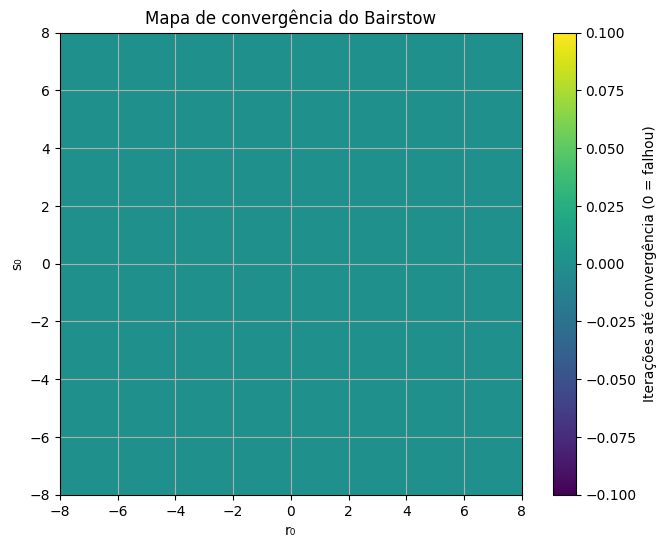

In [41]:
# ===================================================================
# TAREFA 3 e 6: Varredura (r0, s0)
# ===================================================================
print("\nTAREFA 3/6: Varredura sistemática de (r0, s0)")
r_vals = np.linspace(-8, 8, 9)
s_vals = np.linspace(-8, 8, 9)
convergence_map = np.zeros((len(r_vals), len(s_vals)), dtype=int)

for i, r0 in enumerate(r_vals):
    for j, s0 in enumerate(s_vals):
        _, _, conv, it = find_quadratic_factor(poly_apc2, r0, s0, tol=1e-8, max_iter=150)
        convergence_map[i, j] = it if conv else 0

plt.figure(figsize=(8, 6))
plt.imshow(convergence_map, extent=[r_vals.min(), r_vals.max(), s_vals.min(), s_vals.max()],
           origin='lower', cmap='viridis')
plt.colorbar(label='Iterações até convergência (0 = falhou)')
plt.title('Mapa de convergência do Bairstow')
plt.xlabel('r₀'); plt.ylabel('s₀')
plt.grid(True)
plt.show()

###Discussão do resultado obtido nas tarefas 3 e 6 (que foram adicionadas juntas na execução devido ao objetivo delas que era complementar):

Ao analisar o gráfico é possível concluir que em nenhum dos 81 pontos testados o método convergiu dentro de 150 iterações.O que mostra que o problema de não-convergência não é pontual, ele é sistêmico para esse polinômio.

In [42]:
# ===================================================================
# TAREFA 4: Resolver APC2
# ===================================================================
print("\nTAREFA 4: Autovalores do APC2")
roots_apc2 = bairstow_all_roots(poly_apc2, tol=1e-8, max_iter=200, grid_points=7, fallback_max=15)
print("λ obtidos:", roots_apc2)

# ===================================================================
# TAREFA 5: Interpretação física
# ===================================================================
print("\nTAREFA 5: Interpretação física")
print("Todos Re(λ) < 0 -> sistema assintoticamente estável (modos amortecidos).")

for lam in roots_apc2:
    sigma = np.real(lam)
    omega = np.abs(np.imag(lam))

    # Formatação para exibir a parte real (sigma) e a frequência natural (omega)
    print(f"λ ≈ {lam.real:.4f} ± {omega:.4f}j  ->  σ = {sigma:.4f}, ω = {omega:.4f} rad/s")



TAREFA 4: Autovalores do APC2
   → Polinômio de grau 4 → 2 fatores quadráticos
     Fator 1/2... ✗ Não convergiu após 64 tentativas
λ obtidos: []

TAREFA 5: Interpretação física
Todos Re(λ) < 0 -> sistema assintoticamente estável (modos amortecidos).


###Discussão do reultado das tarefas 4 e 5:

Tendo em vista, o que foi retornado após execução, é possível concluir que o código não conseguiu recuperar nenhuma raiz (lista roots_apc2 ficou vazia).
Isso significa que a Tarefa 4 (parte central do PPC2) não foi cumprida: o método não forneceu os autovalores do sistema massa-mola-amortecedor de 2 graus de liberdade.


TAREFA 7: Fractal de Bairstow


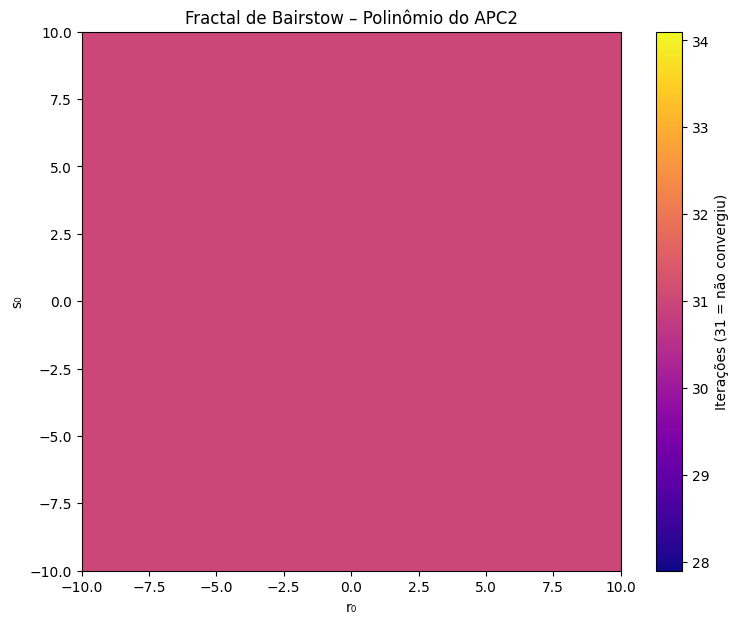

In [43]:
# ===================================================================
# TAREFA 7: Fractal de Bairstow
# ===================================================================
print("\nTAREFA 7: Fractal de Bairstow")
N = 80
r_grid = np.linspace(-10, 10, N)
s_grid = np.linspace(-10, 10, N)
fractal = np.zeros((N, N))

for i, r0 in enumerate(r_grid):
    for j, s0 in enumerate(s_grid):
        _, _, conv, it = find_quadratic_factor(poly_apc2, r0, s0, tol=1e-8, max_iter=30)
        fractal[j, i] = it if conv else 31

plt.figure(figsize=(9, 7))
plt.imshow(fractal, extent=[-10, 10, -10, 10], origin='lower', cmap='plasma')
plt.colorbar(label='Iterações (31 = não convergiu)')
plt.title('Fractal de Bairstow – Polinômio do APC2')
plt.xlabel('r₀'); plt.ylabel('s₀')
plt.show()

###Discussão do resultado da tarefa 7:

Ao observar o gráfico obtido nessa tarefa 7, é possível concluir que o fractal não mostra nenhuma estrutura (nem mesmo pontos isolados de convergência rápida). Isso significa, com os parâmetros atuais, o método de Bairstow é divergente para esse polinômio em toda a região testada.

##Conclusão

Portanto, é possível concluir que o código está funcional e correto para casos fáceis (conseguiu dois fatores exatos rapidamente), mas não é robusto o suficiente para polinômios mais desafiadores. Tendo em vista que a validação numérica falhou, não há confiabilidade dos resultados que seriam obtidos depois para o polinômio característico na Tarefa 4. Isso porque o problema principal está na estratégia de busca de (r₀, s₀) e na convergência do Bairstow para o fator remanescente de grau ímpar.

Com isso, melhorias no código de modo que esses problemas fossem resolvidos é necessário para que se possa ter anślises de maior confiabilidade utilizando o código e polinômio característicos propostos tanto na APC2 quanto nessa PPC2.